In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.feature_selection import SelectKBest, f_regression
import xgboost as xgb
import warnings
import gdown
import os
warnings.filterwarnings('ignore')

In [2]:
# Download dataset from Google Drive
#
url = "https://drive.google.com/uc?id=1ge7BEcNZ_1huTwWGPMYgQh04GUVe4wXZ"
output = "data/pubg_processed.csv"

os.makedirs("data", exist_ok=True)
gdown.download(url, output, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1ge7BEcNZ_1huTwWGPMYgQh04GUVe4wXZ
To: C:\Users\Owner\Desktop\Comp Sci Year 3\CS3072 Final Year Project\Python\data\pubg_processed.csv
100%|██████████| 12.6M/12.6M [00:00<00:00, 16.2MB/s]


'data/pubg_processed.csv'

In [3]:
# Set style for visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("=" * 40)
print("AI-DRIVEN DYNAMIC DIFFICULTY ADJUSTMENT - COMPLETE PIPELINE")
print("=" * 40)

AI-DRIVEN DYNAMIC DIFFICULTY ADJUSTMENT - COMPLETE PIPELINE


In [4]:
df = pd.read_csv("C:data\\pubg_processed.csv")

print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head())

print(f"\nDataset Info:")
print(df.info())

print(f"\nBasic Statistics:")
print(df.describe())

Dataset shape: (154796, 14)

First few rows:
               Id         groupId         matchId  assists  boosts  \
0  315c96c26c9aac  de04010b3458dd  6dc8ff871e21e6        0       0   
1  311b84c6ff4390  eaba5fcb7fc1ae  292611730ca862        0       0   
2  b7807186e3f679  3c08e461874749  2c30ddf481c52d        0       1   
3  92022479b92ce7  2f2c33f548c4b9  07948d723b9c0f        0       3   
4  47143f942503e0  e17a8867a393ec  bc2faecb77e5ec        0       0   

   damageDealt  DBNOs  headshotKills  killPoints  kills  winPoints  \
0      100.000      0              0           0      1          0   
1        8.538      0              0        1000      0       1500   
2      324.200      0              1         986      4       1462   
3      254.300      0              0           0      2          0   
4      136.900      0              0           0      1          0   

   winPlacePerc  group_size matchType  
0        0.1875           1      Solo  
1        0.7368           1      

In [5]:
# ============================================================================
# STEP 2: DATA CLEANING
# ============================================================================
print("\n[STEP 2] Data Cleaning...")

# Check for missing values
print(f"\nMissing values per column:")
print(df.isnull().sum())

# Remove missing values
df = df.dropna()

# Remove outliers (using IQR method for key features)
def remove_outliers(df, columns, threshold=3):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - threshold * IQR
        upper_bound = Q3 + threshold * IQR
        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    return df

outlier_columns = ['kills', 'damageDealt']
original_size = len(df)
df = remove_outliers(df, outlier_columns)
print(f"Removed {original_size - len(df)} outliers ({((original_size - len(df))/original_size)*100:.2f}%)")

# Remove identifier columns
df_clean = df.drop(['Id', 'groupId', 'matchId', 'matchType', 'group_size'], axis=1)
print(f"\nCleaned dataset shape: {df_clean.shape}")


[STEP 2] Data Cleaning...

Missing values per column:
Id               0
groupId          0
matchId          0
assists          0
boosts           0
damageDealt      0
DBNOs            0
headshotKills    0
killPoints       0
kills            0
winPoints        0
winPlacePerc     0
group_size       0
matchType        0
dtype: int64
Removed 5811 outliers (3.75%)

Cleaned dataset shape: (148985, 9)


In [6]:
# ============================================================================
# STEP 3: FEATURE ENGINEERING
# ============================================================================
print("\n[STEP 3] Feature Engineering...")

# Create derived features
df_clean['kill_efficiency'] = df_clean['kills'] / (df_clean['damageDealt'] + 1)
df_clean['headshot_rate'] = df_clean['headshotKills'] / (df_clean['kills'] + 1)
# df_clean['assist_ratio'] = df_clean['assists'] / (df_clean['kills'] + df_clean['assists'] + 1)
# df_clean['DBNO_conversion'] = df_clean['kills'] / (df_clean['DBNOs'] + 1)
# df_clean['boost_efficiency'] = (df_clean['kills'] + df_clean['assists']) / (df_clean['boosts'] + 1)
# df_clean['total_distance'] = df_clean['walkDistance'] + df_clean['rideDistance']
# df_clean['combat_score'] = df_clean['kills'] + df_clean['assists'] + (df_clean['damageDealt'] / 100)
# df_clean['survival_score'] = df_clean['walkDistance'] + df_clean['rideDistance']

print(f"Added {2} engineered features")
print(f"New feature list: {list(df_clean.columns)}")


[STEP 3] Feature Engineering...
Added 2 engineered features
New feature list: ['assists', 'boosts', 'damageDealt', 'DBNOs', 'headshotKills', 'killPoints', 'kills', 'winPoints', 'winPlacePerc', 'kill_efficiency', 'headshot_rate']



[STEP 4] Creating Visualizations...


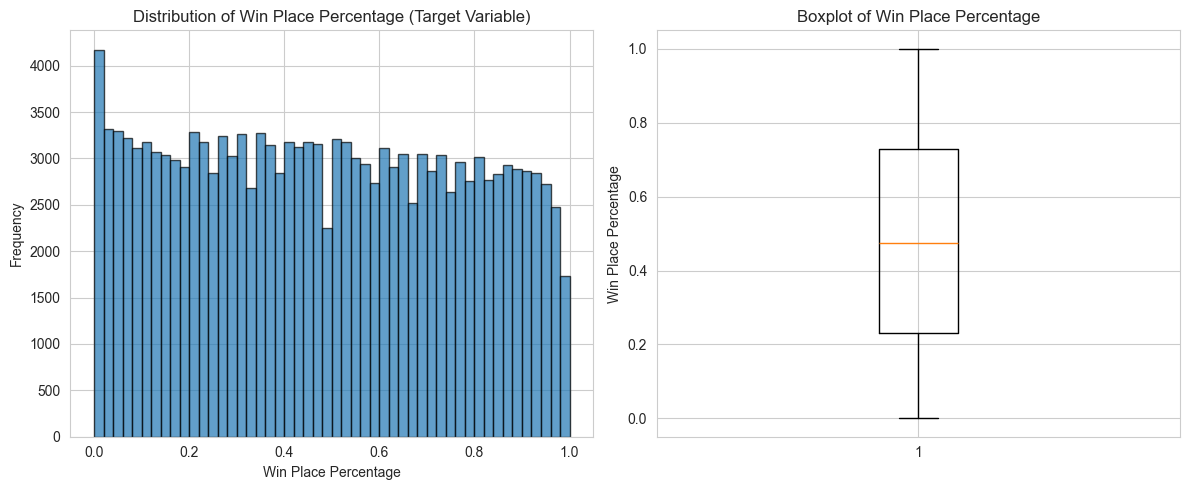

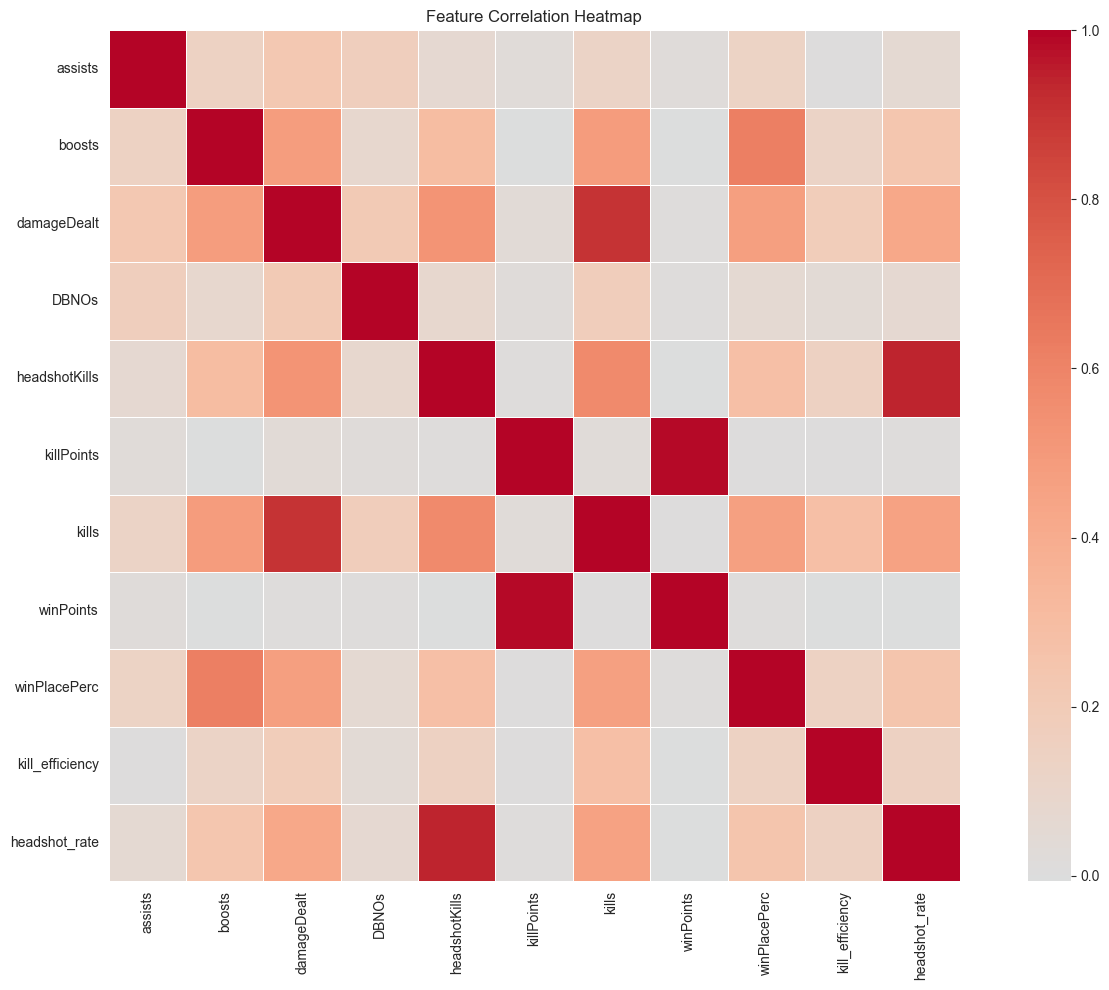


Top 10 features correlated with winPlacePerc:
winPlacePerc       1.000000
boosts             0.623494
damageDealt        0.474938
kills              0.468863
headshotKills      0.287533
headshot_rate      0.251236
kill_efficiency    0.141329
assists            0.134197
DBNOs              0.063122
winPoints          0.009331
killPoints         0.007843
Name: winPlacePerc, dtype: float64


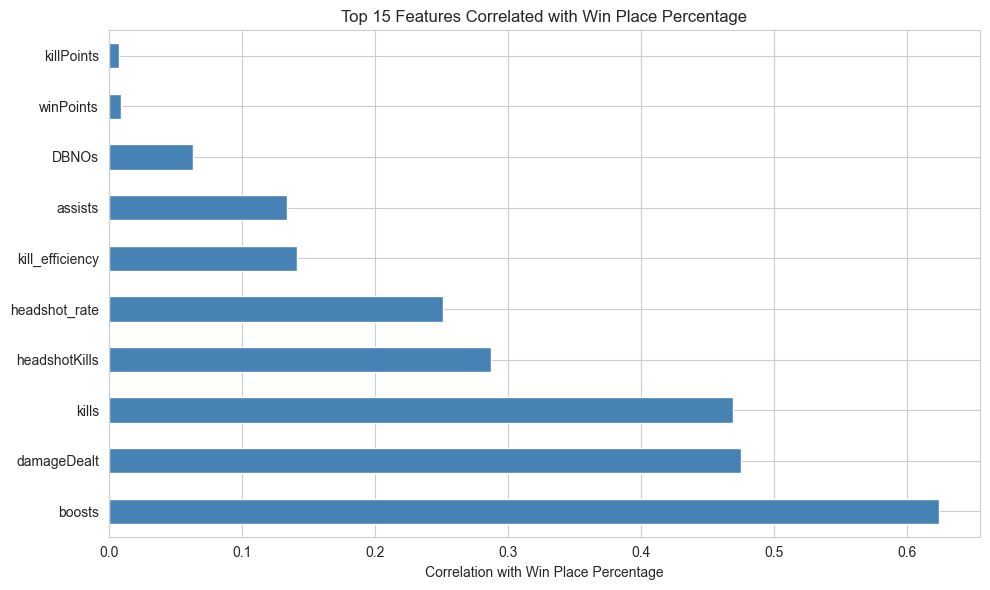

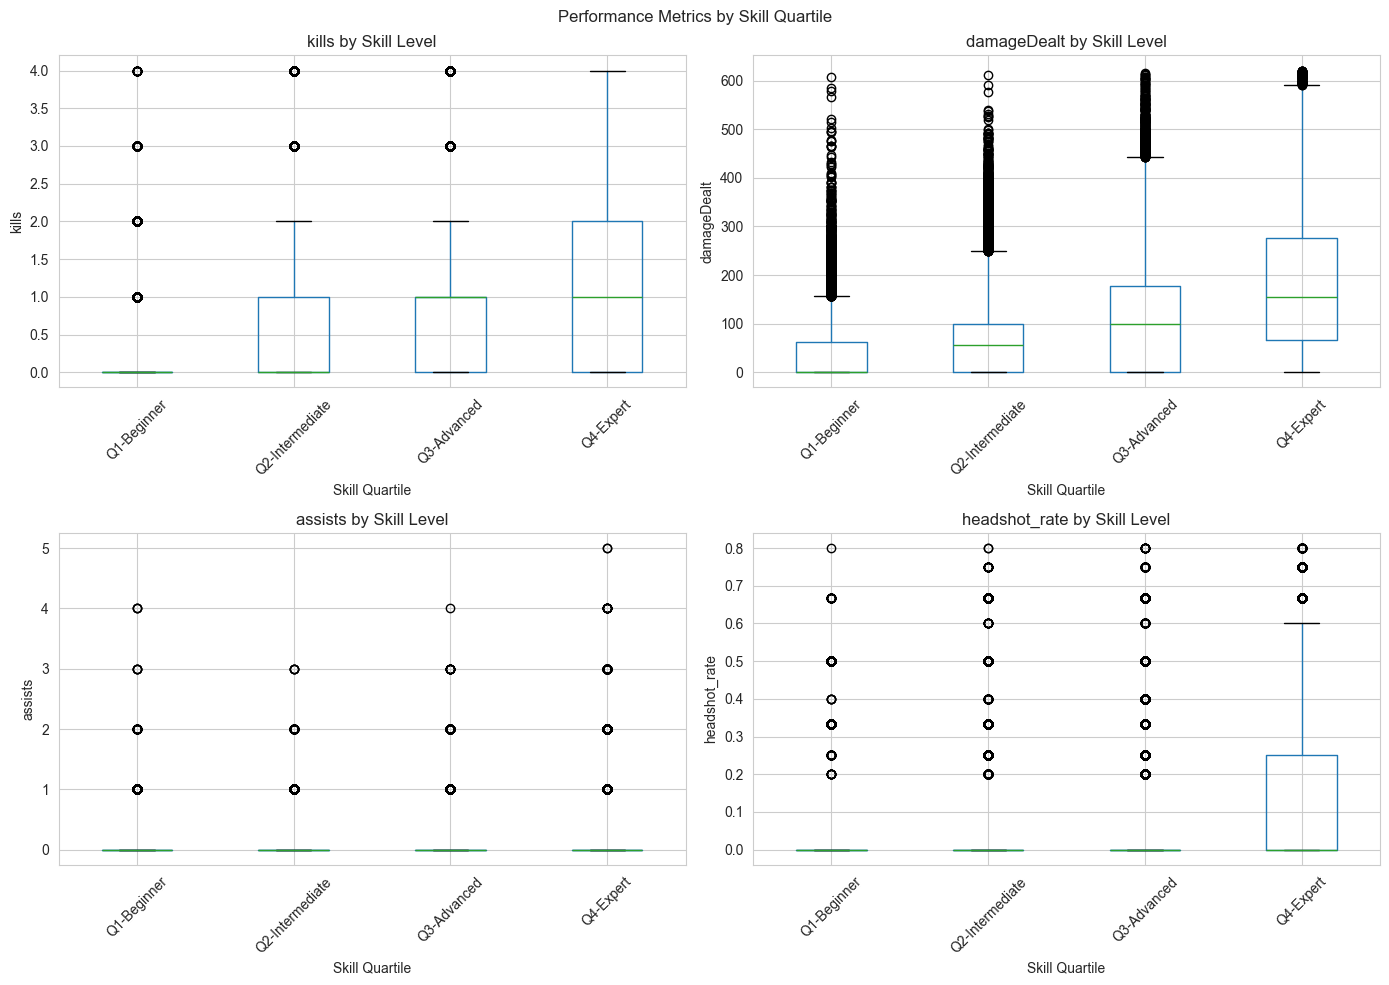

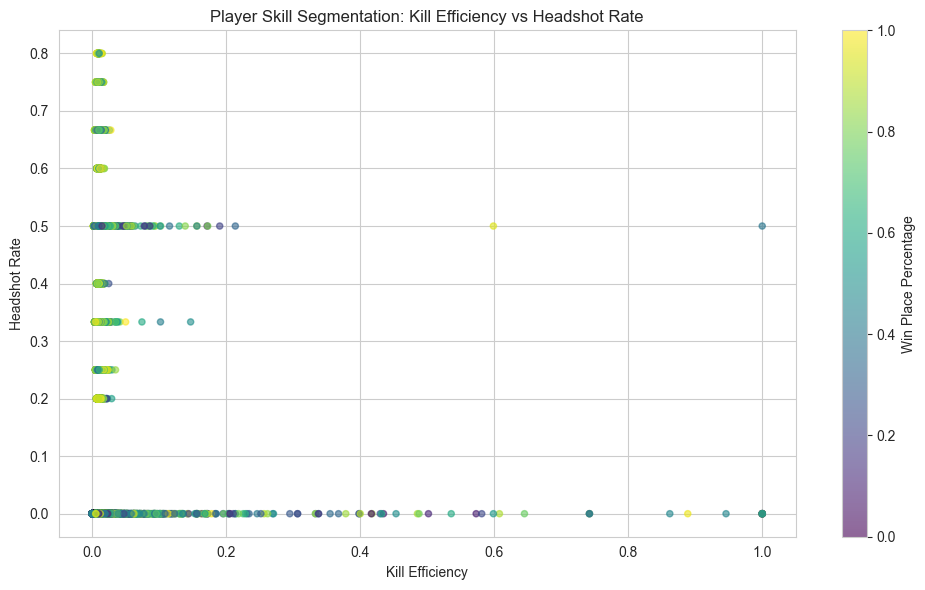

In [7]:
# ============================================================================
# STEP 4: EXPLORATORY DATA ANALYSIS & VISUALIZATIONS
# ============================================================================
print("\n[STEP 4] Creating Visualizations...")

# 4.1 Target Distribution
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(df_clean['winPlacePerc'], bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Win Place Percentage')
plt.ylabel('Frequency')
plt.title('Distribution of Win Place Percentage (Target Variable)')

plt.subplot(1, 2, 2)
plt.boxplot(df_clean['winPlacePerc'])
plt.ylabel('Win Place Percentage')
plt.title('Boxplot of Win Place Percentage')
plt.tight_layout()
plt.show()
# plt.savefig('1_target_distribution.png', dpi=300, bbox_inches='tight')
# print("✓ Saved: 1_target_distribution.png")
# plt.close()

# 4.2 Correlation Heatmap
plt.figure(figsize=(14, 10))
correlation_matrix = df_clean.corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()
# plt.savefig('2_correlation_heatmap.png', dpi=300, bbox_inches='tight')
# print("✓ Saved: 2_correlation_heatmap.png")
# plt.close()

# 4.3 Top correlations with target
target_corr = correlation_matrix['winPlacePerc'].sort_values(ascending=False)
print(f"\nTop 10 features correlated with winPlacePerc:")
print(target_corr.head(11))  # 11 to include target itself

plt.figure(figsize=(10, 6))
target_corr_top = target_corr[1:16]  # Exclude target itself, top 15
target_corr_top.plot(kind='barh', color='steelblue')
plt.xlabel('Correlation with Win Place Percentage')
plt.title('Top 15 Features Correlated with Win Place Percentage')
plt.tight_layout()
plt.show()
# plt.savefig('3_feature_correlation_with_target.png', dpi=300, bbox_inches='tight')
# print("✓ Saved: 3_feature_correlation_with_target.png")
# plt.close()

# 4.4 Performance distributions by skill quartiles
df_clean['skill_quartile'] = pd.qcut(df_clean['winPlacePerc'], q=4, labels=['Q1-Beginner', 'Q2-Intermediate', 'Q3-Advanced', 'Q4-Expert'])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
features_to_plot = ['kills', 'damageDealt', 'assists', 'headshot_rate']

for idx, feature in enumerate(features_to_plot):
    ax = axes[idx // 2, idx % 2]
    df_clean.boxplot(column=feature, by='skill_quartile', ax=ax)
    ax.set_title(f'{feature} by Skill Level')
    ax.set_xlabel('Skill Quartile')
    ax.set_ylabel(feature)
    plt.sca(ax)
    plt.xticks(rotation=45)

plt.suptitle('Performance Metrics by Skill Quartile')
plt.tight_layout()
plt.show()
# plt.savefig('4_performance_by_skill.png', dpi=300, bbox_inches='tight')
# print("✓ Saved: 4_performance_by_skill.png")
# plt.close()

# 4.5 Skill segmentation scatter
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df_clean['kill_efficiency'], df_clean['headshot_rate'],
                     c=df_clean['winPlacePerc'], cmap='viridis', alpha=0.6, s=20)
plt.colorbar(scatter, label='Win Place Percentage')
plt.xlabel('Kill Efficiency')
plt.ylabel('Headshot Rate')
plt.title('Player Skill Segmentation: Kill Efficiency vs Headshot Rate')
plt.tight_layout()
plt.show()
# plt.savefig('5_skill_segmentation.png', dpi=300, bbox_inches='tight')
# print("✓ Saved: 5_skill_segmentation.png")
# plt.close()

# Drop temporary column
df_clean = df_clean.drop('skill_quartile', axis=1)

In [8]:
# ============================================================================
# STEP 5: FEATURE SELECTION
# ============================================================================
print("\n[STEP 5] Feature Selection...")

# Separate features and target
X = df_clean.drop('winPlacePerc', axis=1)
y = df_clean['winPlacePerc']

# Remove highly correlated features (>0.95)
corr_matrix = X.corr().abs()
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper_triangle.columns if any(upper_triangle[column] > 0.95)]
print(f"Removing {len(to_drop)} highly correlated features: {to_drop}")
X = X.drop(columns=to_drop)

# Statistical feature selection
print("\nPerforming statistical feature selection...")
selector = SelectKBest(score_func=f_regression, k=min(15, X.shape[1]))
selector.fit(X, y)

# Get feature scores
feature_scores = pd.DataFrame({
    'Feature': X.columns,
    'Score': selector.scores_
}).sort_values('Score', ascending=False)

print(f"\nTop features by F-statistic:")
print(feature_scores.head(15))

# Keep top features
selected_features = feature_scores.head(15)['Feature'].tolist()
X_selected = X[selected_features]

print(f"\nFinal feature set ({len(selected_features)} features): {selected_features}")



[STEP 5] Feature Selection...
Removing 1 highly correlated features: ['winPoints']

Performing statistical feature selection...

Top features by F-statistic:
           Feature         Score
1           boosts  94750.057107
2      damageDealt  43393.693098
6            kills  41979.786004
4    headshotKills  13427.349037
8    headshot_rate  10037.255725
7  kill_efficiency   3036.397837
0          assists   2732.208083
3            DBNOs    595.975908
5       killPoints      9.165450

Final feature set (9 features): ['boosts', 'damageDealt', 'kills', 'headshotKills', 'headshot_rate', 'kill_efficiency', 'assists', 'DBNOs', 'killPoints']


In [9]:
# ============================================================================
# STEP 6: DATA SPLITTING AND SCALING
# ============================================================================
print("\n[STEP 6] Splitting and Scaling Data...")

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")

# Scale features
scaler = RobustScaler()  # Robust to outliers
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for feature names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("✓ Data scaled using RobustScaler")



[STEP 6] Splitting and Scaling Data...
Training set size: (119188, 9)
Test set size: (29797, 9)
✓ Data scaled using RobustScaler


In [10]:
# =========================================================================
# STEP 7: MODEL TRAINING
# =========================================================================
print("\n[STEP 7] Training Models...")

# Model 1: Random Forest (Baseline)
print("\nTraining Random Forest Regressor...")
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=42,
    n_jobs= -1
)
rf_model.fit(X_train_scaled, y_train)
print("✓ Random Forest trained")



[STEP 7] Training Models...

Training Random Forest Regressor...
✓ Random Forest trained



[STEP 8] Model Evaluation...

Random Forest Performance:
  MAE:  0.1604
  RMSE: 0.2001
  R²:   0.5171


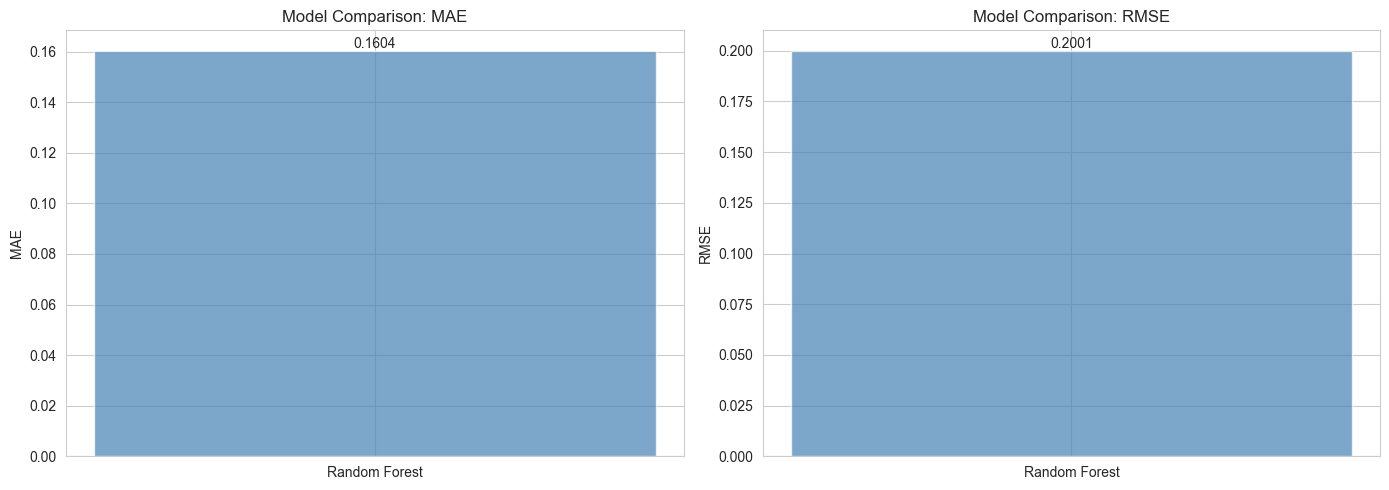


✓ Saved: 6_model_comparison.png


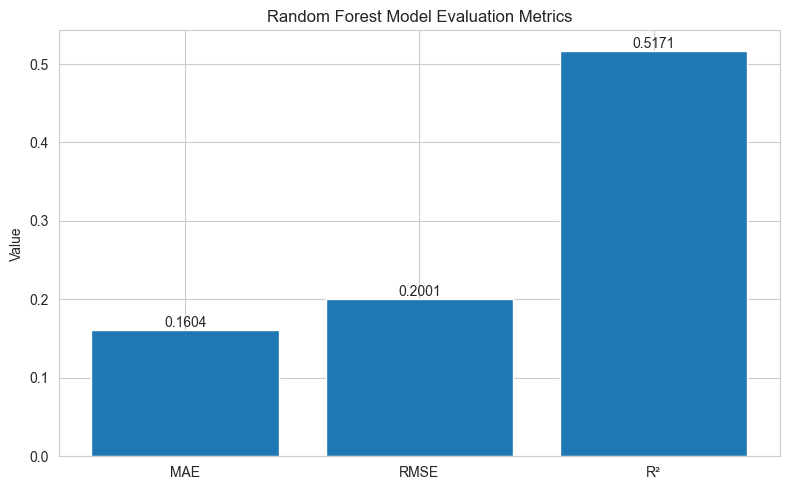

In [11]:
# =========================================================================
# STEP 8: MODEL EVALUATION
# =========================================================================
print("\n[STEP 8] Model Evaluation...")

# Predictions
rf_pred = rf_model.predict(X_test_scaled)

# Calculate metrics
def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"\n{model_name} Performance:")
    print(f"  MAE:  {mae:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  R²:   {r2:.4f}")

    return mae, rmse, r2

rf_metrics = evaluate_model(y_test, rf_pred, "Random Forest")

# Model comparison visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = ['Random Forest']
metrics_data = [rf_metrics]

for idx, metric_name in enumerate(['MAE', 'RMSE']):
    ax = axes[idx]
    values = [m[idx] for m in metrics_data]
    bars = ax.bar(models, values, color=['steelblue', 'orange'], alpha=0.7)
    ax.set_ylabel(metric_name)
    ax.set_title(f'Model Comparison: {metric_name}')

    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()
plt.savefig('6_model_comparison.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: 6_model_comparison.png")
plt.close()

metric_names = ["MAE", "RMSE", "R²"]
metric_values = [rf_metrics[0], rf_metrics[1], rf_metrics[2]]

plt.figure(figsize=(8, 5))
bars = plt.bar(metric_names, metric_values)

plt.ylabel("Value")
plt.title("Random Forest Model Evaluation Metrics")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.4f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.savefig("graph1_model_metrics.png", dpi=300, bbox_inches="tight")
plt.show()


[STEP 9] Analyzing Feature Importance...

Top 10 Most Important Features (RandomForest):
           Feature  Importance
0           boosts    0.822041
1      damageDealt    0.062240
5  kill_efficiency    0.055550
8       killPoints    0.032328
2            kills    0.016450
7            DBNOs    0.004841
6          assists    0.002978
4    headshot_rate    0.002262
3    headshotKills    0.001311


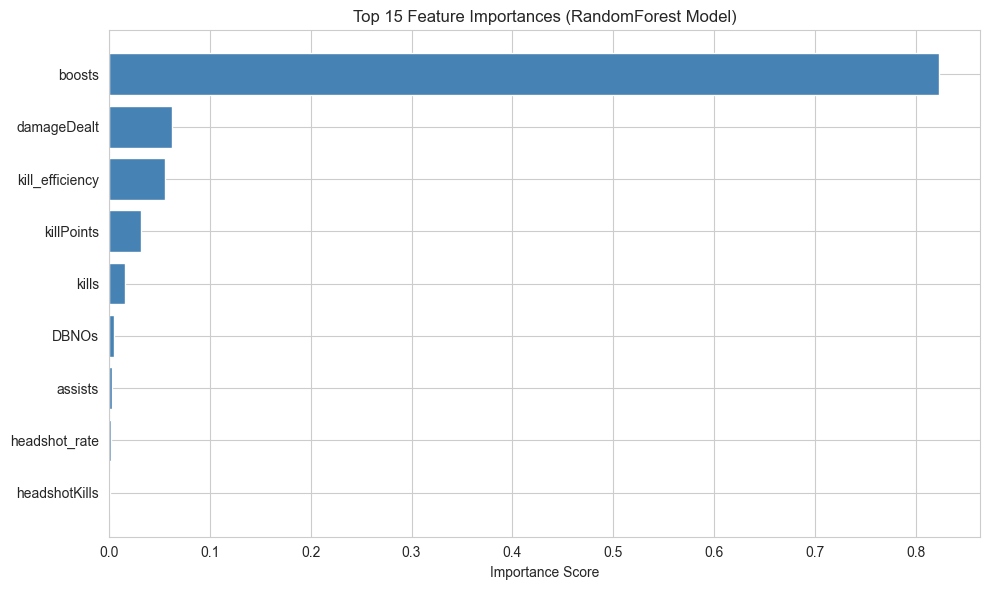

In [12]:
# =========================================================================
# STEP 9: FEATURE IMPORTANCE
# =========================================================================
print("\n[STEP 9] Analyzing Feature Importance...")

# XGBoost feature importance
rf_importance = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 Most Important Features (RandomForest):")
print(rf_importance.head(10))

# Visualization
plt.figure(figsize=(10, 6))
top_features = rf_importance.head(15)
plt.barh(range(len(top_features)), top_features['Importance'], color='steelblue')
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('Importance Score')
plt.title('Top 15 Feature Importances (RandomForest Model)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
# plt.savefig('7_feature_importance.png', dpi=300, bbox_inches='tight')
# print("✓ Saved: 7_feature_importance.png")
# plt.close()



[STEP 10] Visualizing Predictions...


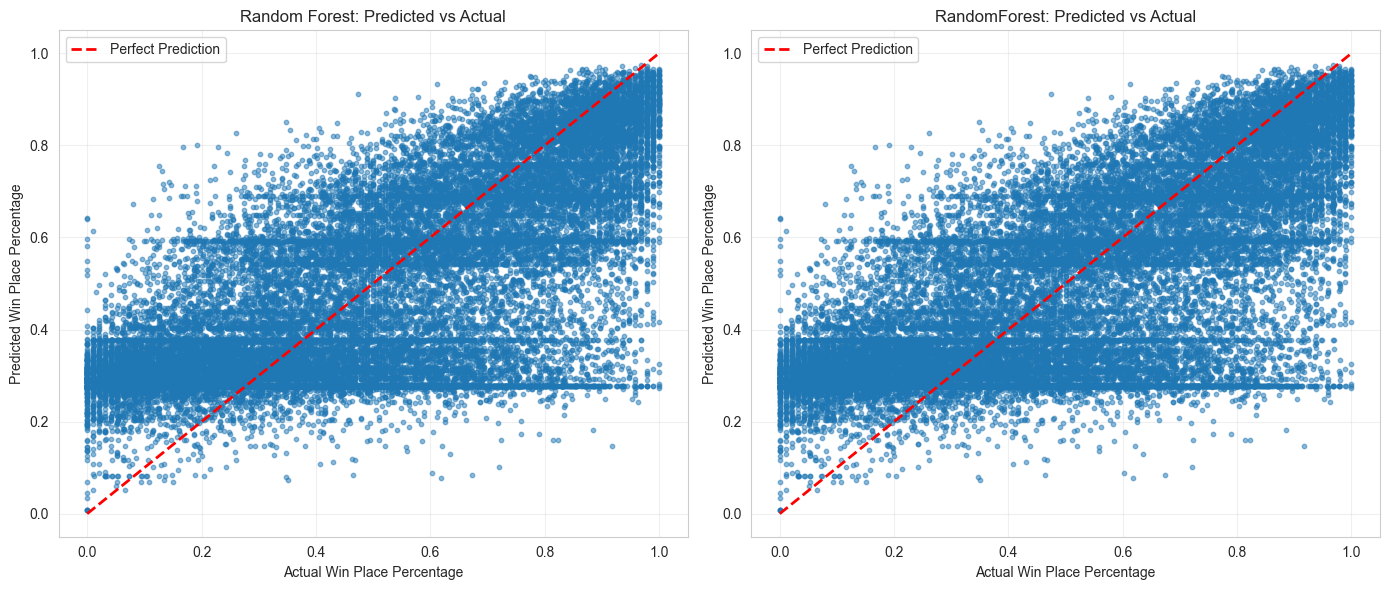

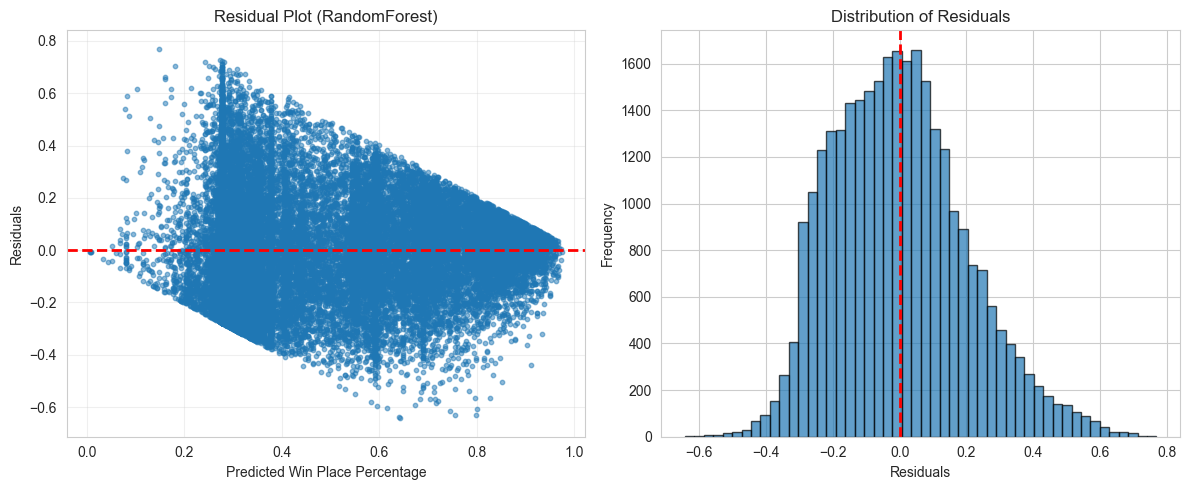

In [13]:
# =========================================================================
# STEP 10: PREDICTION VISUALIZATION
# =========================================================================
print("\n[STEP 10] Visualizing Predictions...")

# Prediction vs Actual scatter plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, (pred, model_name) in enumerate([(rf_pred, 'Random Forest'), (rf_pred, 'RandomForest')]):
    ax = axes[idx]
    ax.scatter(y_test, pred, alpha=0.5, s=10)
    ax.plot([0, 1], [0, 1], 'r--', lw=2, label='Perfect Prediction')
    ax.set_xlabel('Actual Win Place Percentage')
    ax.set_ylabel('Predicted Win Place Percentage')
    ax.set_title(f'{model_name}: Predicted vs Actual')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
# plt.savefig('8_prediction_vs_actual.png', dpi=300, bbox_inches='tight')
# print("✓ Saved: 8_prediction_vs_actual.png")
# plt.close()

# Residual analysis
residuals_xgb = y_test - rf_pred

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(rf_pred, residuals_xgb, alpha=0.5, s=10)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Predicted Win Place Percentage')
plt.ylabel('Residuals')
plt.title('Residual Plot (RandomForest)')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(residuals_xgb, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals')
plt.axvline(x=0, color='r', linestyle='--', lw=2)

plt.tight_layout()
plt.show()
# plt.savefig('9_residual_analysis.png', dpi=300, bbox_inches='tight')
# print("✓ Saved: 9_residual_analysis.png")
# plt.close()

In [15]:
# ========================================================
# STEP 11: DYNAMIC DIFFICULTY ADJUSTMENT SYSTEM
# ========================================================
print("\n[STEP 11] Implementing Dynamic Difficulty Adjustment System...")

def classify_skill_level(win_place_perc):
    """Classify player skill based on predicted win placement"""
    if win_place_perc < 0.25:
        return "Easy", 1
    elif win_place_perc < 0.50:
        return "Medium", 2
    elif win_place_perc < 0.75:
        return "Hard", 3
    else:
        return "Very Hard", 4

def adjust_difficulty(skill_level, skill_score):
    """Determine difficulty adjustments based on skill level"""
    adjustments = {
        "Beginner": {
            "enemy_accuracy": 0.6,  # Reduced
            "enemy_count": 0.8,     # Reduced
            "loot_quality": 1.3,    # Increased
            "aim_assist": 1.5,      # Enabled
            "damage_taken_multiplier": 0.8
        },
        "Medium": {
            "enemy_accuracy": 0.85,
            "enemy_count": 1.0,
            "loot_quality": 1.1,
            "aim_assist": 1.2,
            "damage_taken_multiplier": 1.0
        },
        "Hard": {
            "enemy_accuracy": 1.0,
            "enemy_count": 1.2,
            "loot_quality": 1.0,
            "aim_assist": 1.0,
            "damage_taken_multiplier": 1.1
        },
        "Very Hard": {
            "enemy_accuracy": 1.2,
            "enemy_count": 1.5,
            "loot_quality": 0.9,
            "aim_assist": 0.8,
            "damage_taken_multiplier": 1.2
        }
    }
    return adjustments[skill_level]

# Test the system with sample players
print("\nTesting Dynamic Difficulty Adjustment System:")
print("-" * 80)

sample_players = X_test_scaled.sample(5, random_state=42)
predictions = rf_model.predict(sample_players)

for i, (idx, player) in enumerate(sample_players.iterrows()):
    pred_perc = predictions[i]
    actual_perc = y_test.loc[idx]
    skill_level, skill_score = classify_skill_level(pred_perc)
    adjustments = adjust_difficulty(skill_level, skill_score)

    print(f"\nPlayer {i+1}:")
    print(f"  Predicted Win Place: {pred_perc:.3f} | Actual: {actual_perc:.3f}")
    print(f"  Skill Level: {skill_level} (Score: {skill_score})")
    print(f"  Difficulty Adjustments:")
    for key, value in adjustments.items():
        print(f"    - {key}: {value:.2f}x")

# Visualize skill distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
skill_levels = [classify_skill_level(p)[0] for p in rf_pred]
skill_counts = pd.Series(skill_levels).value_counts()
colors = ['#ff6b6b', '#ffd93d', '#6bcf7f', '#4d96ff']
plt.bar(skill_counts.index, skill_counts.values, color=colors, alpha=0.7)
plt.xlabel('Skill Level')
plt.ylabel('Number of Players')
plt.title('Distribution of Predicted Player Skill Levels')

plt.subplot(1, 2, 2)
skill_scores = [classify_skill_level(p)[1] for p in rf_pred]
plt.hist(rf_pred, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
plt.axvline(x=0.25, color='red', linestyle='--', label='Easy/Medium')
plt.axvline(x=0.50, color='orange', linestyle='--', label='Medium/Hard')
plt.axvline(x=0.75, color='green', linestyle='--', label='Hard/Very Hard')
plt.xlabel('Predicted Win Place Percentage')
plt.ylabel('Frequency')
plt.title('Skill Thresholds on Predicted Distribution')
plt.legend()

plt.tight_layout()
plt.savefig('10_skill_distribution.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: 10_skill_distribution.png")
plt.close()


[STEP 11] Implementing Dynamic Difficulty Adjustment System...

Testing Dynamic Difficulty Adjustment System:
--------------------------------------------------------------------------------

Player 1:
  Predicted Win Place: 0.278 | Actual: 0.785
  Skill Level: Medium (Score: 2)
  Difficulty Adjustments:
    - enemy_accuracy: 0.85x
    - enemy_count: 1.00x
    - loot_quality: 1.10x
    - aim_assist: 1.20x
    - damage_taken_multiplier: 1.00x

Player 2:
  Predicted Win Place: 0.813 | Actual: 0.675
  Skill Level: Very Hard (Score: 4)
  Difficulty Adjustments:
    - enemy_accuracy: 1.20x
    - enemy_count: 1.50x
    - loot_quality: 0.90x
    - aim_assist: 0.80x
    - damage_taken_multiplier: 1.20x

Player 3:
  Predicted Win Place: 0.464 | Actual: 0.100
  Skill Level: Medium (Score: 2)
  Difficulty Adjustments:
    - enemy_accuracy: 0.85x
    - enemy_count: 1.00x
    - loot_quality: 1.10x
    - aim_assist: 1.20x
    - damage_taken_multiplier: 1.00x

Player 4:
  Predicted Win Place: 0.309 

In [ ]:
# =========================================================================
# STEP 12: SAVE MODEL AND ARTIFACTS
# =========================================================================
print("\n[STEP 12] Saving Model and Artifacts...")

# Save the trained model
joblib.dump(rf_model, 'rf_difficulty_model.pkl')
print("✓ Saved: rf_difficulty_model.pkl")

# Save the scaler
joblib.dump(scaler, 'feature_scaler.pkl')
print("✓ Saved: feature_scaler.pkl")

# Save feature names
joblib.dump(selected_features, 'selected_features.pkl')
print("✓ Saved: selected_features.pkl")
with open('selected_features.txt', 'w') as f:
    f.write('\n'.join(selected_features))
print("✓ Saved: selected_features.txt")

# Save model metrics
with open('model_performance.txt', 'w') as f:
    f.write("MODEL PERFORMANCE SUMMARY\n")
    f.write("=" * 50 + "\n\n")
    # f.write(f"XGBoost Model:\n")
    # f.write(f"  MAE:  {xgb_metrics[0]:.4f}\n")
    # f.write(f"  RMSE: {xgb_metrics[1]:.4f}\n")
    # f.write(f"  R²:   {xgb_metrics[2]:.4f}\n\n")
    f.write(f"Random Forest Model:\n")
    f.write(f"  MAE:  {rf_metrics[0]:.4f}\n")
    f.write(f"  RMSE: {rf_metrics[1]:.4f}\n")
    f.write(f"  R²:   {rf_metrics[2]:.4f}\n")
print("✓ Saved: model_performance.txt")